# Analiza podatkov

V tem dokumentu bomo analizirali podatke o knjiga

In [43]:
import pandas as pd

knjige = pd.read_csv("knjige.csv", index_col="id")

In [44]:
knjige.head(5)

,naslov,id_avtorja,povprecna_ocena,stevilo_ocen,stevilo_recenzij,stevilo_strani,jezik,leto_izdaje,trenutno_bere,opis
id,,,,,,,,,,
2767052,"The Hunger Games (The Hunger Games, #1)",153394.0,4.35,10080244,268807,374.0,English,2008.0,110226,Winning means fame and fortune. Losing means c...
1885,Pride and Prejudice,1265.0,4.30,4900979,153011,279.0,English,2023.0,256801,"Since its immediate success in 1813, Pride and..."
2657,To Kill a Mockingbird,1825.0,4.26,6993055,135628,323.0,English,2006.0,100313,"""Shoot all the bluejays you want, if you can h..."
58613451,Harry Potter and the Order of the Phoenix (Har...,1077326.0,4.50,3856441,80331,896.0,English,2003.0,92198,It's official: the evil Lord Voldemort has ret...
19063,The Book Thief,11466.0,4.39,2925868,163395,592.0,English,2006.0,105296,Librarian's note: An alternate cover edition c...


In [45]:
knjige.tail(5)

,naslov,id_avtorja,povprecna_ocena,stevilo_ocen,stevilo_recenzij,stevilo_strani,jezik,leto_izdaje,trenutno_bere,opis
id,,,,,,,,,,
157981682,The Book of Love,24902.0,3.50,11400,2452,628.0,English,2024.0,2340,The Book of Love showcases Kelly Link at the h...
3109,The Omnivore's Dilemma: A Natural History of F...,2121.0,4.19,211330,14727,450.0,English,2006.0,11578,What should we have for dinner? For omnivore l...
264,The Portrait of a Lady,159.0,3.80,85922,4573,797.0,English,2003.0,5653,"When Isabel Archer, a beautiful, spirited Amer..."
18521,A Room of One’s Own,6765.0,4.22,270127,26348,112.0,English,2000.0,22308,A Room of One's Own is an extended essay by Vi...
38374795,Howards End,86404.0,3.96,95726,5081,318.0,English,2018.0,3803,Howards End is considered by many to be E. M. ...


In [46]:
knjige[["naslov", "povprecna_ocena"]]

,naslov,povprecna_ocena
id,,
2767052,"The Hunger Games (The Hunger Games, #1)",4.35
1885,Pride and Prejudice,4.30
2657,To Kill a Mockingbird,4.26
58613451,Harry Potter and the Order of the Phoenix (Har...,4.50
19063,The Book Thief,4.39
...,...,...
157981682,The Book of Love,3.50
3109,The Omnivore's Dilemma: A Natural History of F...,4.19
264,The Portrait of a Lady,3.80


In [47]:
knjige["povprecna_ocena"] + knjige["stevilo_recenzij"]

id
2767052      268811.35
1885         153015.30
2657         135632.26
58613451      80335.50
19063        163399.39
               ...    
157981682      2455.50
3109          14731.19
264            4576.80
18521         26352.22
38374795       5084.96
Length: 1000, dtype: float64

In [48]:
knjige["leto_izdaje"] = knjige["leto_izdaje"].astype("Int64")

In [49]:
knjige["desetletje"] = (knjige["leto_izdaje"] // 10) * 10

In [50]:
najboljse_leto = knjige[knjige["leto_izdaje"] == 2006]

In [51]:
najboljse_leto.sort_values("povprecna_ocena", ascending=False).head(10)

,naslov,id_avtorja,povprecna_ocena,stevilo_ocen,stevilo_recenzij,stevilo_strani,jezik,leto_izdaje,trenutno_bere,opis,desetletje
id,,,,,,,,,,,
68428,"Mistborn: The Final Empire (Mistborn, #1)",38550.0,4.49,1024372,86091,541.0,English,2006,73899,"What if the whole world were a dead, blasted w...",2000
42900,"Lover Awakened (Black Dagger Brotherhood, #3)",20248.0,4.43,190179,8568,434.0,English,2006,2993,"In the shadows of the night in Caldwell, New Y...",2000
19063,The Book Thief,11466.0,4.39,2925868,163395,592.0,English,2006,105296,Librarian's note: An alternate cover edition c...,2000
1617,Night,1049.0,4.38,1383340,43481,120.0,English,2006,13920,"Born in the town of Sighet, Transylvania, Elie...",2000
4069,Man's Search for Meaning,2782.0,4.37,906068,51099,165.0,English,2006,75348,Psychiatrist Viktor Frankl's memoir has rivete...,2000
166997,Stoner,51229.0,4.35,269712,35955,292.0,English,2006,14458,William Stoner is born at the end of the ninet...,2000
7445,The Glass Castle,3275.0,4.33,1384396,73535,288.0,English,2006,24391,THE #1 NEW YORK TIMES BESTSELLER The Glass Cas...,2000
228086938,Banker's Holiday: A Novel of Fiscal Irregularity,808471.0,4.33,6138,29,336.0,English,2006,7,"From the first puzzling sentence, Banker's Hol...",2000
35729,"Lover Eternal (Black Dagger Brotherhood, #2)",20248.0,4.32,203464,8328,441.0,English,2006,3551,"In the shadows of the night in Caldwell, New Y...",2000


In [52]:
knjige.groupby("desetletje").size()

desetletje
1970     13
1980     36
1990    144
2000    467
2010    243
2020     88
dtype: int64

In [53]:
ocena_po_desetletjih = knjige.groupby("desetletje")["povprecna_ocena"].mean()

<Axes: xlabel='desetletje'>

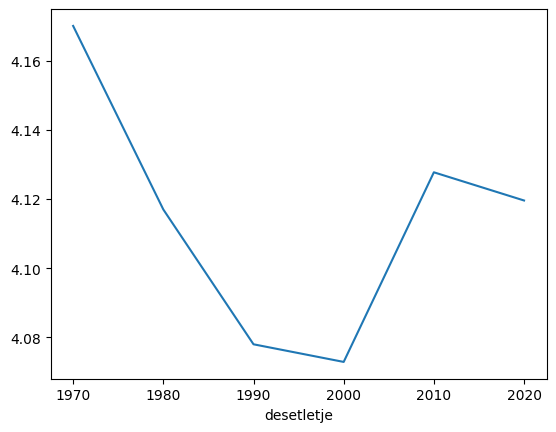

In [54]:
ocena_po_desetletjih.plot()

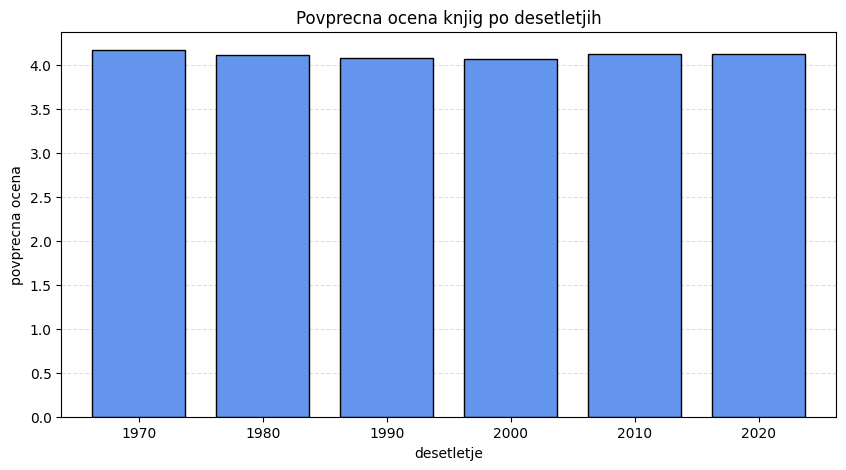

In [55]:
ax = ocena_po_desetletjih.plot.bar(
    figsize=(10, 5),
    color="cornflowerblue",
    edgecolor="black",
    width=0.75
)
ax.set_title("Povprecna ocena knjig po desetletjih")
ax.set_xlabel("desetletje")
ax.set_ylabel("povprecna ocena")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.tick_params(axis="x", rotation=0)